In [6]:
import os
import random
from typing import Dict

import numpy as np
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm

from graph_utils import prepare_traj
from torch_simulator_64 import DifferentiableCompression64
from utils import calc_p_ratio_box_tensor, to_f32, to_f64


### Load data

#### Coarse-grained data

In [2]:
dataset_type = "node_optimized" # "node_optimized" | "stiffness_optimized"
if dataset_type not in {"node_optimized", "stiffness_optimized"}:
    raise ValueError(f"Probably incorrect data type, expected 'node_optimized' or 'stiffness_optimized', got {dataset_type}. ")

data_dir = os.path.join("./demo_data", f"data_{dataset_type}_40sims.pt")
data = torch.load(data_dir, weights_only=False)

for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5}"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"Train data: {len(data['train'])} sims.")
print(f"FT data:    {len(data['ft'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


test : 100%|██████████| 10/10 [00:00<00:00, 30.80it/s]

Train data: 10 sims.
FT data:    10 sims.
Val data:   10 sims.
Test data:  10 sims.


#### Show $\nu$ distribution

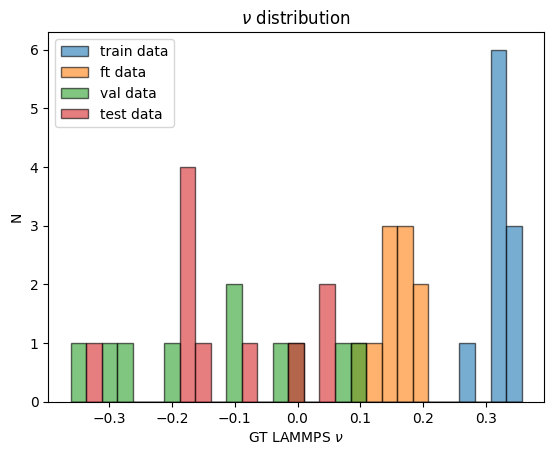

In [5]:
def visualize_nu_disribution(data: Dict):
    ps = {}
    all_values = []

    for data_type, sims in data.items():
        ps[data_type] = [calc_p_ratio_box_tensor(sim).item() for sim in sims]
        all_values.extend(ps[data_type])

    min_val = min(all_values)
    max_val = max(all_values)
    common_bins = np.linspace(min_val, max_val, 30) 

    for data_type, values in ps.items():
        plt.hist(
        values, 
        bins=common_bins, 
        edgecolor='black', 
        alpha=0.6, 
        label=f"{data_type} data"
    )

    plt.title("$\\nu$ distribution")
    plt.xlabel("GT LAMMPS $\\nu$")
    plt.ylabel("N")
    plt.legend()
    plt.show()

visualize_nu_disribution(data)


### Define shared plotting parameters

In [ ]:
params = {
    'font.size': 8,                 # Base font size
    'axes.labelsize': 8,            # Axis labels (e.g., nu_gt)
    'axes.titlesize': 8,            # Subplot titles
    'xtick.labelsize': 7,           # Tick numbers
    'ytick.labelsize': 7,   
    'legend.fontsize': 6,           # Make legend smaller to fit
    'lines.markersize': 4,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Your target size
    'figure.dpi': 200,              # High DPI for clear viewing
    'font.family': 'serif',         # Matches most LaTeX/Paper fonts
}
plt.rcParams.update(params)

### Simple test & box evolution

In [ ]:
steps = 10_000
device = "cpu"
results = {
    "position_mse": [],
    "gt_box_change": [],
    "gt_box_p": [],
    "custom_box_p": [],
    "custom_box_change": [],
}

test_data = []
for k, v in data.items():
    test_data.extend(v)
sims = random.sample(test_data, k=20)

for sim in tqdm(sims):
    simulator: DifferentiableCompression64 = DifferentiableCompression64(
        num_particles=sim[0].num_nodes,
        mass=1.0e6,
        dt=0.01,
        damp=10.0,
        ptemp=1e-4,
        pdamp=1000,
        target_p=0.0,
        srate=1e-5,
        temp_langevin=1e-7,
        factor_two=True,
    )

    strain = (sim[0].box.x - sim[-1].box.x) / sim[0].box.x
    assumed_rollout_length = int(strain / 1e-5 / 0.01)
    dump_period = int(assumed_rollout_length / len(sim)) + 1
    data_step0 = sim[0].to(device)

    simulator_rollout, conditions = simulator.run_simulator(
        initial_data=to_f64(data_step0),
        steps=steps,
        debug=False,
        device=device,
        r0=data_step0.edge_attr[:, -2],
    )

    # coarse grain to match GT Lammps 
    simulator_rollout = [step for i, step in enumerate(simulator_rollout) if i % dump_period == 0]
    target_idx = len(simulator_rollout) - 1

    # collect results
    gt_box_change = [graph.box_tensor.cpu().detach() for graph in sim[:target_idx]]
    results["gt_box_change"].append(gt_box_change)

    custom_box_change = [graph.box_tensor.cpu().detach() for graph in simulator_rollout[:target_idx]]
    results["custom_box_change"].append(custom_box_change)

    mse = torch.nn.functional.mse_loss(simulator_rollout[-1].x, sim[target_idx].x).item()
    results["position_mse"].append(mse)

    gt_box_p = calc_p_ratio_box_tensor(sim, target_idx)
    results["gt_box_p"].append(gt_box_p.item())

    custom_box_p = calc_p_ratio_box_tensor(simulator_rollout, target_idx)
    results["custom_box_p"].append(custom_box_p.item())


In [ ]:
rand_i = random.randint(0, len(results["custom_box_change"])-1)

fig, ax = plt.subplots(1, 2, layout="constrained", sharex=True, figsize=(7, 3.5))

ax[0].plot([box[1] for box in results["custom_box_change"][rand_i]], label="Custom $L_y$")
ax[0].plot([box[1] for box in results["gt_box_change"][rand_i]], label="GT LAMMPS $L_y$")
ax[0].legend()
ax[0].set_ylabel("$L_y$")

ax[1].plot([box[0] for box in results["custom_box_change"][rand_i]], label="Custom $L_x$")
ax[1].plot([box[0] for box in results["gt_box_change"][rand_i]], label="GT LAMMPS $L_x$")
ax[1].legend()
ax[1].set_ylabel("$L_x$")

plt.show()


In [ ]:
fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(7, 3.5))

ax[0].scatter(results["gt_box_p"], results["custom_box_p"])
ax[0].set_xlabel("GT LAMMPS $\\nu$")
ax[0].set_ylabel("Custom $\\nu$")
ax[0].set_title(f"$R^2={r2_score(results['gt_box_p'], results['custom_box_p']):.3f}$")

ax[1].hist(results["position_mse"])
ax[1].set_xlabel("Position MSE")
ax[1].set_ylabel("N")
ax[1].set_title("Position MSE")

plt.show()

#### Check diffirentiability

In [ ]:
sim = random.sample(test_data, k=1)[0]
data_step0 = sim[0].to(device)

data_step0.x = data_step0.x.double()
data_step0.x.requires_grad_(True)

simulator = DifferentiableCompression64(
    num_particles=sim[0].num_nodes,
    mass=1.0e6,
    dt=0.01,
    damp=10,
    ptemp=1e-4,
    pdamp=1000,
    target_p=0.0,
    srate=1e-5,
    temp_langevin=1e-7,
    factor_two=True
)

traj, cond = simulator.run_simulator(data_step0, 50, debug=False, r0=data_step0.edge_attr[:, -2], device=device)
traj = [to_f32(g) for g in traj]
loss = torch.nn.functional.mse_loss(sim[50].x, data_step0.x)

try:
    grad_check = torch.autograd.grad(loss, data_step0.x, retain_graph=True)
    print(f"Mean grad: {grad_check[0].abs().mean().item()}")
except RuntimeError as e:
    print(f"error: {e}")


#### Compare against large dumpstep data

In [ ]:
steps = 10_000
random_sims = random.sample(test_data, k=20)
device = "cpu"
results = {
    "dangling" : [],
    "position_mse": [],
    "gt_box_change": [],
    "gt_box_p": [],
    "custom_box_p": [],
    "custom_box_change": [],
}
for random_sim in tqdm(random_sims):
    
    sim_len = len(random_sim)
    sim_strain = (random_sim[0].box.x - random_sim[-1].box.x) / random_sim[0].box.x
    assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
    dump_period = int(assumed_rollout_length / sim_len) + 1
    # print(F"Sim strain: {sim_strain:.4f}")
    # print(f"Rollout lenths to reach {sim_strain:.4f} : {assumed_rollout_length}")
    # print(f"Dump period: {dump_period}")
    # print(f"Real dLx: {(random_sim[0].box.x - random_sim[1].box.x):.6f}")

    simulator: DifferentiableCompression64 = DifferentiableCompression64(
        num_particles=random_sim[0].num_nodes,
        mass=1.0e6,
        dt=0.01,
        damp=10.0,
        ptemp=1e-4,
        pdamp=1000.0,
        target_p=0.0,
        srate=1e-5,
        temp_langevin=0.0,
        factor_two=True,
    )

    data_step0 = random_sim[0].to(device)
    simulator_rollout, conditions = simulator.run_simulator(
        initial_data=to_f64(data_step0),
        steps=steps,
        debug=False,
        device=device,
        r0=data_step0.edge_attr[:, -2].double(),
    )

    corresponding_idx = [i for i, g in enumerate(simulator_rollout) if i % dump_period == 0]
    coarse_grained_rollout = [simulator_rollout[i] for i in corresponding_idx]

    # collect results
    target_idx = len(coarse_grained_rollout)
    data_target = random_sim[target_idx-1].to(device)
    gt_box_change = [(graph.box.x, graph.box.y) for graph in random_sim[:target_idx]]
    results["gt_box_change"].append(gt_box_change)

    custom_box_change = [g.box_tensor.cpu().detach() for g in coarse_grained_rollout]
    results["custom_box_change"].append(custom_box_change)

    mse = torch.nn.functional.mse_loss(coarse_grained_rollout[-1].x, data_target.x).item()
    results["position_mse"].append(mse)

    gt_box_p = calc_p_ratio_box_tensor(random_sim[:target_idx])
    results["gt_box_p"].append(gt_box_p.item())

    custom_box_p = calc_p_ratio_box_tensor(coarse_grained_rollout)
    results["custom_box_p"].append(custom_box_p.item())


In [ ]:
i = random.randint(0, len(results["custom_box_change"])-1)

# plt.plot([box[0] for box in results["custom_box_change"][0]], label="est box x")
plt.plot([box[1] - results["custom_box_change"][i][0][1] for box in results["custom_box_change"][i]], label="Custom $L_y$")
# plt.plot([box[0] for box in results["gt_box_change"][0]], label="real box x")
plt.plot([box[1] - results["gt_box_change"][i][0][1] for box in results["gt_box_change"][i]], label="GT LAMMPS $L_y$")
plt.ylabel('dLy')
plt.xlabel('Dump step')
plt.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, layout="tight", figsize=(7, 3.5))

ax[0].scatter(results["gt_box_p"], results["custom_box_p"])
ax[0].set_xlabel("GT LAMMPS $\\nu$")
ax[0].set_ylabel("Custom $\\nu$")
ax[0].set_title(f"$R^2={r2_score(results['gt_box_p'], results['custom_box_p']):.3f}$")

ax[1].hist(results["position_mse"])
ax[1].set_xlabel("Position MSE")
ax[1].set_ylabel("N")
ax[1].set_title("Position MSE")

plt.show()